In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

In [24]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<Axes: xlabel='count', ylabel='Gender'>

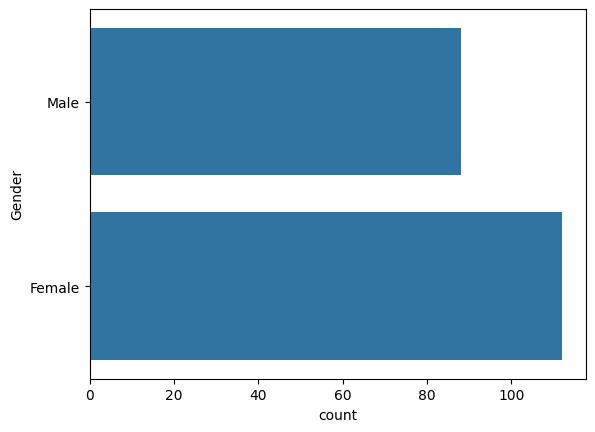

In [25]:
sns.countplot(df['Gender'])

<Axes: >

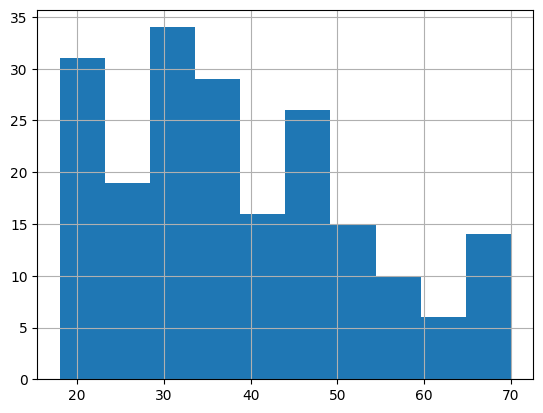

In [26]:
df['Age'].hist()

<Axes: >

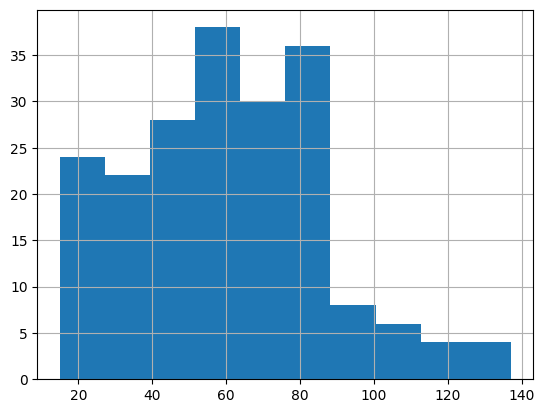

In [27]:
df['Annual Income (k$)'].hist()

<Axes: >

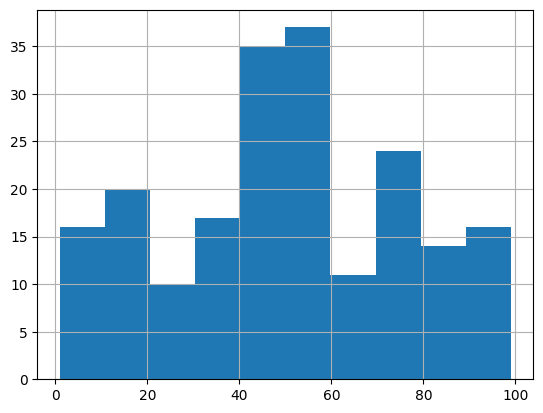

In [28]:
df['Spending Score (1-100)'].hist()

- Age group near 30-40 have the highest density.

- Most customers have income in range of 50-80k.

- Most of the customers have spending score of 50

In [29]:
# missing values
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [30]:
# dropping useless column

df.drop('CustomerID', axis = 1, inplace = True)

In [31]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [32]:
# Encode

df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

In [33]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [34]:
# df.to_csv('mall_customer_processed.csv', index=False) 

In [35]:
org_df = df.copy()
org_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [36]:
# Scale df

scaler = StandardScaler()
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = scaler.fit_transform(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


In [37]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


## PCA

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df = pca.fit_transform(df)

df

array([[-0.60043766, -1.73717898],
       [-1.64988591, -1.78912423],
       [ 0.31538132, -1.69277231],
       [-1.47798868, -1.78131664],
       [-0.06054496, -1.67869121],
       [-1.5029612 , -1.7438065 ],
       [ 1.07202103, -1.58773793],
       [-1.94718878, -1.72769057],
       [ 2.65927595, -1.4504641 ],
       [-0.99141027, -1.64691155],
       [ 2.50988817, -1.45931005],
       [-1.47785399, -1.67316678],
       [ 1.98742066, -1.47928386],
       [-1.43412929, -1.62698028],
       [ 1.01549562, -1.4775323 ],
       [-1.55292967, -1.59402762],
       [ 0.27232193, -1.5119479 ],
       [-1.2997754 , -1.54249961],
       [ 1.33203751, -1.35564719],
       [-1.45726454, -1.51942393],
       [ 0.30455257, -1.3581841 ],
       [-1.24333274, -1.42787781],
       [ 1.644869  , -1.29854428],
       [-0.94101737, -1.37824333],
       [ 1.79852122, -1.18081367],
       [-1.29406171, -1.27973079],
       [ 0.84929965, -1.22201945],
       [-0.41464999, -1.24030551],
       [ 0.6216485 ,

# KMeans

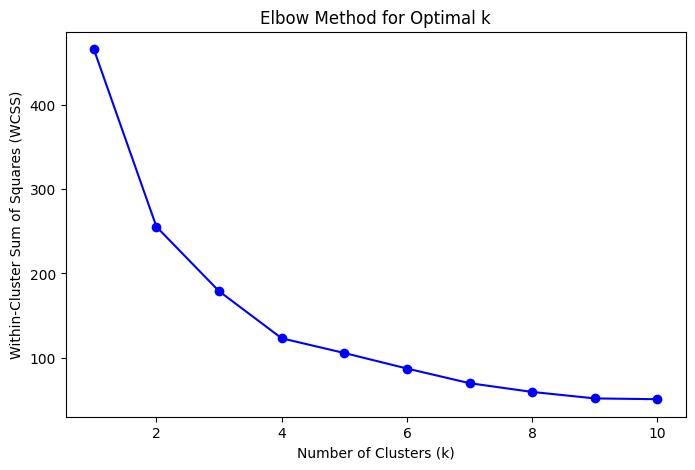

In [39]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    
    kmeans.fit(df)
    
    wcss.append(kmeans.inertia_)

# Elbow method
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [40]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)

kmeans.fit(df)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [41]:
print(kmeans.labels_)

cen = kmeans.cluster_centers_
cen

[2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 1 0 0 2 0 0 0 0 0 2 0 0 1 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0
 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 3 1 3 1 3 1 1 1 3 1 3 1 3 1 3 1 1 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


array([[ 0.97462678, -0.50386263],
       [-1.03926917,  0.64498102],
       [-1.10942652, -1.13755008],
       [ 1.00332613,  1.10862843]])

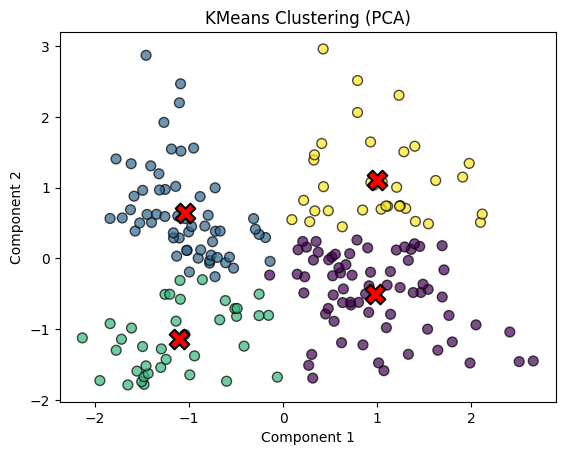

In [42]:
# Plot

plt.scatter(df[:,0], df[:,1], c=kmeans.labels_, s=50, alpha=0.7, edgecolors='black')
plt.scatter(cen[:,0], cen[:,1], marker='X', s=200, color='red', edgecolors='black', linewidths=1.5)
plt.title('KMeans Clustering (PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

In [43]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df, kmeans.labels_)
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.423


In [44]:
from sklearn.metrics import davies_bouldin_score
score = davies_bouldin_score(df, kmeans.labels_)
print(f"Davies Bouldin Score: {round(score, 4)}")

Davies Bouldin Score: 0.819


In [45]:
from sklearn.metrics import calinski_harabasz_score
score = calinski_harabasz_score(df, kmeans.labels_)
print(f"Calinski Harabasz Score : {round(score, 2)}")

Calinski Harabasz Score : 182.21


# DBSCAN

In [47]:
eps_values = [0.35, 0.4, 0.45, 0.5]
min_samples_values = [3, 5, 7, 10]

best_score = -1
best_params = None
best_noise = None
best_clusters = None

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df)
        
        mask = labels != -1
        if sum(mask) < 2:
            continue
        
        labels_clean = labels[mask]
        df_clean = df[mask]
        n_clusters = len(set(labels_clean))
        noise_points = np.sum(labels == -1)
        
        if n_clusters < 2:
            continue
        
        score = silhouette_score(df_clean, labels_clean)
        
        print(f"eps={eps:.2f}, min_samples={min_samples}, clusters={n_clusters}, silhouette={score:.3f}, noise={noise_points}")
        
        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)
            best_noise = noise_points
            best_clusters = n_clusters

print(f"\nBest silhouette score: {best_score:.3f}")
print(f"Best params: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Clusters: {best_clusters}, Noise points: {best_noise}")

eps=0.35, min_samples=3, clusters=6, silhouette=0.137, noise=18
eps=0.35, min_samples=5, clusters=4, silhouette=0.382, noise=42
eps=0.35, min_samples=7, clusters=5, silhouette=0.360, noise=52
eps=0.35, min_samples=10, clusters=4, silhouette=0.621, noise=98
eps=0.40, min_samples=3, clusters=3, silhouette=0.178, noise=11
eps=0.40, min_samples=5, clusters=2, silhouette=0.367, noise=29
eps=0.40, min_samples=7, clusters=3, silhouette=0.492, noise=39
eps=0.40, min_samples=10, clusters=3, silhouette=0.567, noise=56
eps=0.45, min_samples=3, clusters=2, silhouette=0.205, noise=6
eps=0.45, min_samples=7, clusters=2, silhouette=0.368, noise=31
eps=0.45, min_samples=10, clusters=2, silhouette=0.400, noise=46
eps=0.50, min_samples=10, clusters=2, silhouette=0.380, noise=35

Best silhouette score: 0.621
Best params: eps=0.35, min_samples=10
Clusters: 4, Noise points: 98


## Train the model with Best hyperparameters

In [52]:
dbscan = DBSCAN(eps=0.35, min_samples=10)

labels = dbscan.fit_predict(df)

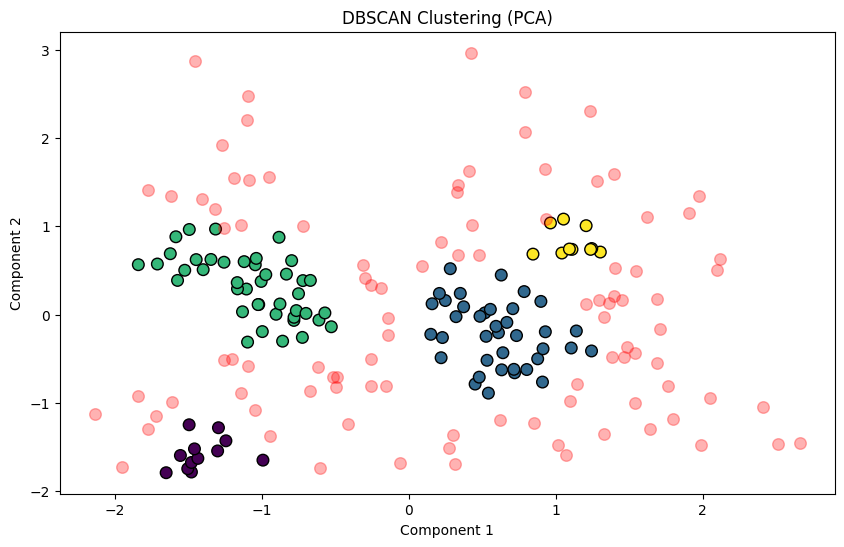

In [53]:
plt.figure(figsize=(10, 6))

# clusters (not noise)
plt.scatter(df[labels != -1, 0], df[labels != -1, 1],
            c=labels[labels != -1],
            s=70, alpha=1, edgecolors='black')

# noise points
plt.scatter(df[labels == -1, 0], df[labels == -1, 1],
            c='red', s=70, alpha=0.3)

plt.title('DBSCAN Clustering (PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.show()

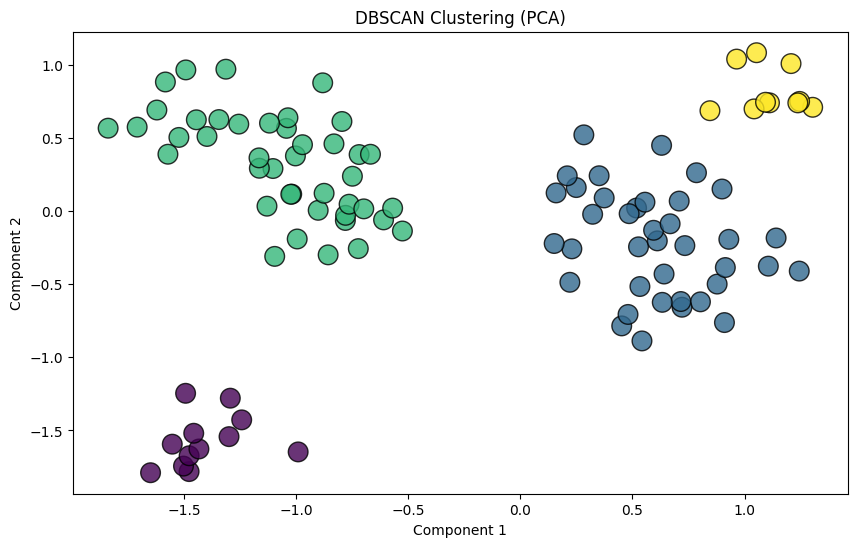

In [54]:
plt.figure(figsize=(10, 6))

# normal clusters
plt.scatter(df[labels != -1, 0], df[labels != -1, 1],
            c=labels[labels != -1],
            s=200, alpha=0.8, edgecolors='black')

plt.title('DBSCAN Clustering (PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.show()

In [55]:
from sklearn.metrics import silhouette_score

# remove noise
mask = labels != -1
df_clean = df[mask]
labels_clean = labels[mask]

score = silhouette_score(df_clean, labels_clean)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.621


In [56]:
from sklearn.metrics import davies_bouldin_score
score = davies_bouldin_score(df_clean, labels_clean)
print(f"Davies Bouldin Score: {round(score, 4)}")

Davies Bouldin Score: 0.4643


In [57]:
from sklearn.metrics import calinski_harabasz_score
score = calinski_harabasz_score(df_clean, labels_clean)
print(f"Calinski Harabasz Score: {round(score, 2)}")

Calinski Harabasz Score: 234.56


In [322]:
noise_points = np.sum(labels == -1)
print(f"Number of noise points: {noise_points}")

Number of noise points: 98


| Metric             | K-Means      | DBSCAN          | Notes                               |
| ------------------ | ------------ | --------------- | ----------------------------------- |
| Silhouette Score   | 0.42         | 0.621           | K-Means better for compact clusters |
| Calinski-Harabasz  | Low       | High          | Shows cluster separation            |
| Davies-Bouldin     | Higher | Lower Better | Measures cluster similarity         |
| Number of clusters | 4  | 4            | DBSCAN automatically chooses        |
| Noise points       | 0            | 98           | DBSCAN detects outliers             |
| Visual plot        | Spherical    | Arbitrary shape | Outliers visible in DBSCAN          |


> Although K-Means performs well for compact and spherical clusters, DBSCAN achieved a higher silhouette score in our experiment. 

> This is because DBSCAN removes noise points, leading to more clearly separated clusters.

> Additionally, DBSCAN automatically determines the number of clusters and detects outliers, which K-Means cannot do.

# Model Pipeline 

In [323]:
org_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [324]:
numerical = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("Scaler", StandardScaler(), numerical)
    ])

preprocessor


,transformers,"[('Scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [325]:
from sklearn.pipeline import Pipeline

db_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('PCA', PCA(n_components=2)),
    ('dbscan', DBSCAN(eps=0.35, min_samples=10))
])

db_pipeline.fit(org_df)

,steps,"[('preprocessing', ...), ('PCA', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [326]:
labels = db_pipeline['dbscan'].labels_

X_pca = db_pipeline['PCA'].transform(
    db_pipeline['preprocessing'].transform(org_df)
)

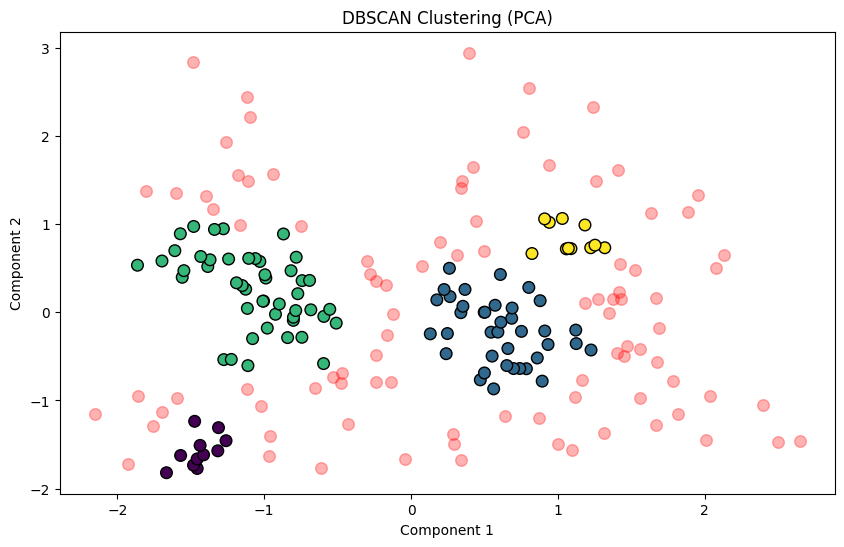

In [327]:
plt.figure(figsize=(10, 6))

# clusters (not noise)
plt.scatter(X_pca[labels != -1, 0], X_pca[labels != -1, 1],
            c=labels[labels != -1],
            s=70, alpha=1, edgecolors='black')

# noise points
plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1],
            c='red', s=70, alpha=0.3)

plt.title('DBSCAN Clustering (PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.show()

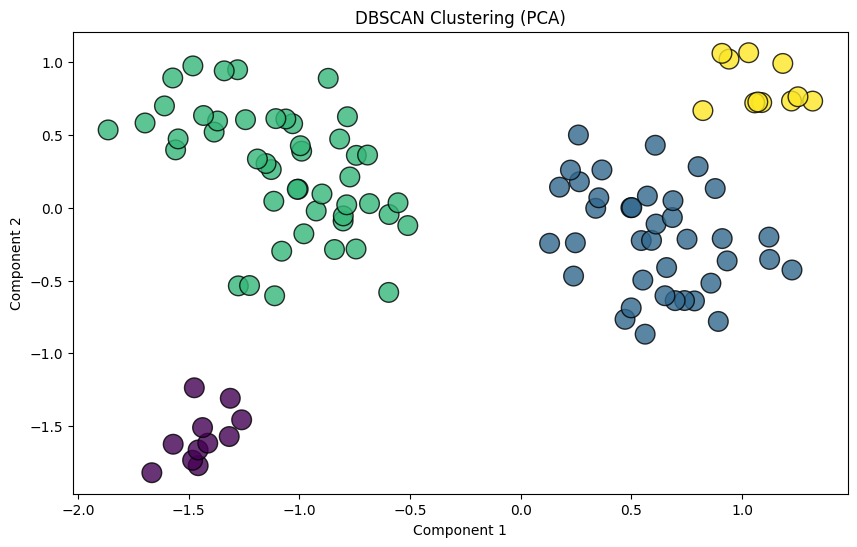

In [334]:
plt.figure(figsize=(10, 6))

# normal clusters
plt.scatter(X_pca[labels != -1, 0], X_pca[labels != -1, 1],
            c=labels[labels != -1],
            s=200, alpha=0.8, edgecolors='black')

plt.title('DBSCAN Clustering (PCA)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.show()

In [335]:
mask = labels != -1
df_clean = X_pca[mask]
labels_clean = labels[mask]

score = silhouette_score(df_clean, labels_clean)
print("Silhouette score:", round(score, 3))

noise_points = np.sum(labels == -1)
print(f"Number of noise points: {noise_points}")

Silhouette score: 0.598
Number of noise points: 93


In [336]:
# Save model

import pickle

with open('dbscan_pipeline.pkl', 'wb') as f:
    pickle.dump(db_pipeline, f)


In [337]:
# Load saved pipeline
with open('dbscan_pipeline.pkl', 'rb') as f:
    model = pickle.load(f)

In [339]:
# Ask user for input
age = float(input("Enter Age: "))
income = float(input("Enter Annual Income (k$): "))
spending_score = float(input("Enter Spending Score (1-100): "))

gender = input("Enter Gender (Male/Female): ").capitalize()
gender_num = 0 if gender == 'Male' else 1

# Create new dataframe from user input
new_data = pd.DataFrame({
    'Age': [age],
    'Annual Income (k$)': [income],
    'Spending Score (1-100)': [spending_score],
    'Gender_num': [gender_num]
})

# Predict using loaded DBSCAN pipeline
# DBSCAN doesn't have predict method, but we can use fit_predict on the new transformed data
preprocessed_data = db_pipeline['preprocessing'].transform(new_data)
pca_data = db_pipeline['PCA'].transform(preprocessed_data)

labels = db_pipeline['dbscan'].fit_predict(pca_data)

# Show cluster label
if labels[0] == -1:
    print("The data point is classified as NOISE (outlier).")
else:
    print(f"The data point belongs to cluster: {labels[0]}")

The data point is classified as NOISE (outlier).
